# 手撕REINFORCE算法

In [1]:
import gymnasium as gym
import numpy as np
from collections import deque
import random
import torch
from torch import nn
import torch.nn.functional as F
from torch.distributions import Categorical

In [12]:
%%html
<img src="img/CartPole.png", width=800,height=400>

## 策略梯度的计算公式
$$
\nabla_\theta J(\theta)\approx\frac{1}{N}\sum_{i=1}^N\left(\sum_{t=0}^{T}\nabla_\theta\log\pi_\theta(a_t^{(i)}\mid s_t^{(i)})\cdot R(\tau^{(i)})\right)
$$

In [13]:
# 引入环境：“cartpole”
env = gym.make("CartPole-v1")

In [14]:
env.observation_space, env.action_space

(Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32),
 Discrete(2))

In [15]:
state = env.reset()
state

(array([-0.04475585,  0.03706782, -0.02793811, -0.00973759], dtype=float32),
 {})

In [16]:
next_state, reward, done, truncated, info = env.step(0)
next_state, reward, done, truncated, info

(array([-0.0440145 , -0.15764256, -0.02813286,  0.27400124], dtype=float32),
 1.0,
 False,
 False,
 {})

# 定义策略网络

In [17]:
class Policy(nn.Module):
    def __init__(self, in_states, h1_nodes, out_actions):
        super().__init__()

        # 两层全联接网络
        self.fc1 = nn.Linear(in_states, h1_nodes)
        self.out = nn.Linear(h1_nodes, out_actions)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        logits = self.out(x)
        # 这里要输出动作概率分布，用softmax来完成
        prob = F.softmax(logits, dim=-1)
        return prob

# 训练和预测代码

# 开始训练

In [18]:
class REINFORCE():

    # 超参数
    learning_rate = 0.01            # 学习率
    gamma = 0.99                    # 折扣因子
    hidden_size = 32                # 网络隐藏层维度

    # 训练阶段
    def train(self, episodes):
        # 创建环境
        env = gym.make('CartPole-v1')

        num_states = env.observation_space.shape[0]#连续空间用shape[0]
        num_actions = env.action_space.n

        # 创建策略网络
        policy = Policy(in_states=num_states, h1_nodes=self.hidden_size, out_actions=num_actions)

        # 优化器
        self.optimizer = torch.optim.Adam(policy.parameters(), lr=self.learning_rate)

        # 收集每一个episode的reward
        rewards_per_episode = []

        for episode in range(episodes):
            state = env.reset()[0]  # 初始化环境
            done = False

            rewards = []
            log_probs = []

            while not done:
                # 选择 action
                action, log_prob = self.select_action(policy, state)

                # 执行动作
                new_state, reward, terminated, truncated,_ = env.step(action)
                done = terminated or truncated

                # 更新状态
                state = new_state

                # 记录reward和动作概率
                rewards.append(reward)
                log_probs.append(log_prob)


            # 更新回合reward
            rewards_per_episode.append(sum(rewards))

            # 优化模型
            loss = self.optimize(policy, rewards, log_probs)

            # 打印 reward
            if (episode + 1) % 20 == 0:
                print(f"episode {episode + 1}, loss: {loss:.2f}, gain: {np.mean(rewards_per_episode[-100:]):.2f}")

        # 关闭环境
        env.close()

        # 保存训练好的策略网络
        torch.save(policy.state_dict(), "saved/cartpole_reinforce.pt")

        return rewards_per_episode

    def select_action(self, policy, state):
        # 构造输入[1, state_dim]
        state = torch.tensor(state).unsqueeze(0)
        prob = policy(state)

        # 构造一个softmax分布，便于采样
        categorical_dist = Categorical(prob)

        # 采样一个action，这里按照概率来采样
        action = categorical_dist.sample()

        # 拿到对应动作的对数概率
        log_prob = categorical_dist.log_prob(action)

        return action.item(), log_prob


    def optimize(self, policy, rewards, log_probs):
        """优化策略网络"""

        R = 0 # 累计折扣收益
        eps = 1e-7
        policy_loss = []
        discounted_rewards = []
        for r in rewards[::-1]: #倒着计算
            R = r + self.gamma * R
            discounted_rewards.insert(0, R)

        # reward 做一下归一化，方便加速收敛
        discounted_rewards = torch.tensor(discounted_rewards)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + eps)

        # 计算对应动作的logprob和reward
        # zip将俩个对应到一起
        for log_prob, reward in zip(log_probs, discounted_rewards):
            policy_loss.append(-log_prob * reward)

        self.optimizer.zero_grad()
        policy_loss = torch.concat(policy_loss).sum() # 求和
        policy_loss.backward()
        self.optimizer.step()

        return policy_loss.item()

    # 测试阶段
    def test(self, episodes):
        # 初始化环境
        env = gym.make('CartPole-v1', render_mode='human')
        num_states = env.observation_space.shape[0]
        num_actions = env.action_space.n

        # 加载训练好的模型
        policy = Policy(in_states=num_states, h1_nodes=self.hidden_size, out_actions=num_actions)
        policy.load_state_dict(torch.load("saved/cartpole_reinforce.pt"))
        policy.eval()    # 预测模式

        for i in range(episodes):
            state = env.reset()[0]
            done = False
            while(not done):
                with torch.no_grad():
                    state = torch.tensor(state).unsqueeze(0)
                    action = policy(state).argmax().item()
                # 执行动作
                state, reward, terminated, truncated, _  = env.step(action)
                done = terminated or truncated

        env.close()

In [19]:
n_episode = 300
reinforce = REINFORCE()
rewards_per_episode = reinforce.train(n_episode)

episode 20, loss: -0.16, gain: 18.85
episode 40, loss: -0.11, gain: 21.48
episode 60, loss: 0.21, gain: 24.50
episode 80, loss: 0.75, gain: 26.43
episode 100, loss: -1.75, gain: 30.25
episode 120, loss: -3.18, gain: 42.28
episode 140, loss: -0.34, gain: 58.06
episode 160, loss: -5.04, gain: 90.33
episode 180, loss: -13.11, gain: 168.48
episode 200, loss: -10.42, gain: 253.24
episode 220, loss: -1.00, gain: 299.64
episode 240, loss: -0.36, gain: 379.04
episode 260, loss: -11.63, gain: 438.83
episode 280, loss: -5.84, gain: 448.25
episode 300, loss: -0.84, gain: 435.84


# 可视化reward曲线

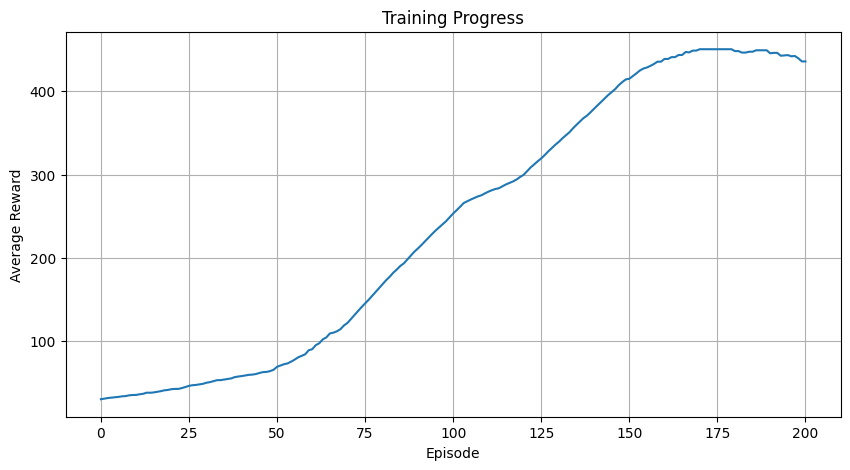

In [20]:
from utils import plot_rewards_curve
plot_rewards_curve(rewards_per_episode)

# 测试环境

In [24]:
reinforce.test(1)